In [3]:
from multiprocessing import Pool,Process,Manager,cpu_count
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
import pickle
from PIL import Image,ImageFilter
import warnings
import scipy.optimize as opt
import scipy as sp
import cmath
import time 
import math
matplotlib.use('Agg')

%matplotlib inline
warnings.filterwarnings('ignore')

font = {'family' : 'Ubuntu',
        'weight' : 'bold',
        'size'   : 30}

matplotlib.rc('font', **font)

from tabulate import tabulate as tb

In [4]:
def ListofFiles(path):
    filelist=[]
    for root, dirs, files in os.walk(path):
        for file in files:
             filelist.append(os.path.join(root,file))
    return filelist

def getImageValues(Files,EventLimit=1,isPrint=False):
    if(type(Files) is list or type(Files) is np.ndarray):
        values={}
        count=0
        for file in Files:
            img1=Image.open(file)
            imgArray=np.array(img1)
            values[count]=imgArray
            count+=1
            if(EventLimit==count):
                break
        if(isPrint):        
            print(f" {count} frames in dictinary ")
        if(count==0):
            print("No Pictures found!")
    else:
        img1=Image.open(Files)
        values=np.array(img1)
    return values

def PickleITDump(data,fileName):
    with open(fileName,'wb') as f:
        pickle.dump(data,f)
        
def PickleITRead(fileName):
    with open(fileName,'rb') as f:
        data=pickle.load(f)
    return data

def MaskCreate(pixel,radius,center,plot=False,sp="Circle"):
    XPixel,YPixel=pixel
    centerX,centerY=center
    x=np.arange(0,XPixel,1)
    y=np.arange(0,YPixel,1)
    xx,yy=np.meshgrid(x,y)
    rr=np.sqrt((xx-centerX)**2+(yy-centerY)**2)
    mask=0
    values=np.zeros(rr.shape)
    if(sp=="Rectangle"):
        rr[centerX-radius[0] :centerX+radius[0],centerY-radius[1] :centerY+radius[1]]=1
        mask=rr==1
        mask=mask.transpose()
    else:
        mask=rr<radius
        
    values[mask]=1       
    
    if(plot):
        plt.figure(figsize=(12,8),dpi=300)
        plt.title("Mask Position")
        plt.xlabel("PixelX")
        plt.ylabel("PixelY")
        plt.imshow(values,cmap="gray",origin="lower",vmin=values.min(),vmax=values.max())
        plt.show()
    
    return mask,values,[centerX,centerY]
## Average the images
def AvergImage(II,rangex,Single=True,start=0,isDic=False):
    img=np.zeros(II[0].shape)
    
    if (rangex>len(II.keys())):
        rangex=len(II.keys())
    # Average only one set
    if(Single):
        for i in range(start,rangex+start):
            img+=II[i]
        img=img/rangex
        return img
    else: # Average Multiple Sets of Images
        cnt=0
        fImages=[]
        fImages_dic={}
        while(cnt<=len(II.keys())-1):
            img+=II[cnt]
            if (cnt%(rangex)==0 and cnt>0):
                fImages.append(img/rangex)
                if(isDic): fImages_dic[cnt]=img/rangex
                
                img=np.zeros(II[0].shape)
            cnt=cnt+1
        if(isDic):    
            return fImages_dic
        else:
            return fImages
    
    
def WeightedAverage(img,mask,Radius,isPrint=False):
    ## Method 2 Weighted Average Estimation
    x = np.linspace(0, img.shape[0], img.shape[0])
    y=  np.linspace(0, img.shape[1], img.shape[1])
    xx, yy = np.meshgrid(x, y)
    
    rr=np.sqrt(xx**2+yy**2)
    
    # Estimate the Max Intensity
    mAx=np.max(img[mask[0]])
    MaxMask2D=mAx==img*mask[0]
    MaxMask1D=mAx==img[mask[0]]
    
    # Estimate the Max Intensity in a given region
    Cmax=(np.where(MaxMask2D)[1],np.where(MaxMask2D)[0])
    
    if(isPrint):
        print(f"Max is {img[Cmax]} at {Cmax}")
    
    ## Create a Mask that is Centered in Maximum Intensity
    if(len(Cmax[0])>1 or len(Cmax[1])>1):
        print(f"CenterX is {Cmax[0]} and CenterY is {Cmax[1]}")
    cc=MaskCreate(img.shape,Radius,(Cmax[0],Cmax[1]),False)
    
    ## Estimate the Mean
    #Mean=np.average(img[cc[0]],weights=rr[cc[0]])
    
        ## Find the Pixel that is closest to mean
    #ErrorV=Error(img[cc[0]],Mean)
    #MinLoc=np.where(ErrorV==np.min(ErrorV))
    #PixelLoc=np.where(img*cc[0]==img[cc[0]][MinLoc])
    #print(PixelLoc)
   
    WeightedPixelX=np.average(xx[cc[0]],weights=img[cc[0]])
    WeightedPixelY=np.average(yy[cc[0]],weights=img[cc[0]])
    
    PixelX=xx[cc[0]]
    PixelY=yy[cc[0]]
    weightsA=img[cc[0]]
    
    np.average(PixelX*PixelY,weights=weightsA)
    if(isPrint):
        print(f"Weighted Average {(WeightedPixelX,WeightedPixelY)} ")
    return [[WeightedPixelX,WeightedPixelY],[Cmax[0][0],Cmax[1][0]]]    
        

In [5]:
#Path="../data/10bar_7days_purified/Camera/CRAB_9_17_2023/17k_8k_7k/22ms/" #(For Slides)
#Path="/media/argon/CRAB/Argon/day2/Pure_Argon_LENS1/S2/22ms"
#Path="/media/argon/Ilker_SSD/XenonRunNewII/8.08bar/S2/440Vpercm/22ms"
#Path="/media/argon/CRAB/Xenon_Methane_Run_NewII/Hotgetter1_4.84/Hotgetter1_4.84/Camera/S2/440VPercm/1s"
#Path="/media/argon/CRAB/XenonRun_NEWII/5.89_Bar/Camera/S2/440Vpercm/22ms/"
#Path="/home/argon/Projects/Ilker/CRAB_Diffusion/data/8.07bar/S2/440V/22ms/"
#Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/5.89_bar/S2/13.5k_8k_7k_II_1.5/440Vpercm/1s/"
#Path="/media/argon/Data/CRAB_NEW_II/data/6bar/22ms"
#Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/5.89_bar/S2/13.5k_8k_7k_II_1.5/440Vpercm/22ms/"
Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/XeCH4_4.98/S2/125VPercm/1s/"
Images=getImageValues(ListofFiles(Path),600)


In [6]:
Test=AvergImage(Images,600,Single=True,start=0)

In [7]:
## 125V/cm
## 6.8 bar Argon #NewII
PixelShape=(512,512)
OffsetY=+42 #-25
OffsetX=-25 #+20

Needle14cmMaskInitial=MaskCreate((PixelShape),50,(215+OffsetX-7-40,270+OffsetY+20))

Needle9cmMaskInitial=MaskCreate(PixelShape,50,(309+OffsetX,306+OffsetY+5))

Needle4cmMaskInitial=MaskCreate(PixelShape,50,(261+OffsetX-5,180+OffsetY-20))

EsitmatedCenter4cm=WeightedAverage(Test,Needle14cmMaskInitial,50)
EsitmatedCenter9cm=WeightedAverage(Test,Needle9cmMaskInitial,50)
EsitmatedCenter14cm=WeightedAverage(Test,Needle4cmMaskInitial,50)

Needle14cmMask=MaskCreate((PixelShape),50,(EsitmatedCenter4cm[0][0],EsitmatedCenter4cm[0][1]))

Needle9cmMask=MaskCreate(PixelShape,50,(EsitmatedCenter9cm[0][0],EsitmatedCenter9cm[0][1]))

Needle4cmMask=MaskCreate(PixelShape,50,(EsitmatedCenter14cm[0][0],EsitmatedCenter14cm[0][1]))

In [8]:
NeedleIntensity4cm=Test[Needle4cmMask[0]]
NeedleIntensity9cm=Test[Needle9cmMask[0]]
NeedleIntensity14cm=Test[Needle14cmMask[0]]
print(f"Needle4cm min {np.min(NeedleIntensity4cm)} mean {np.mean(NeedleIntensity4cm)} max {np.max(NeedleIntensity4cm)}")
print(f"Needle9cm min {np.min(NeedleIntensity9cm)} mean {np.mean(NeedleIntensity9cm)} max {np.max(NeedleIntensity9cm)}")
print(f"Needle14cm min {np.min(NeedleIntensity14cm)} mean {np.mean(NeedleIntensity14cm)} max {np.max(NeedleIntensity14cm)}")


Needle4cm min 2612.076666666667 mean 5747.774861234881 max 33210.41166666667
Needle9cm min 2255.4533333333334 mean 3301.2756503547002 max 13299.441666666668
Needle14cm min 2256.225 mean 3056.105964722364 max 6663.5216666666665


In [7]:
## Get Mean and Sum

Values={"4cm":np.array([]),"9cm":np.array([]),"14cm":np.array([]),"4cm_mean":np.array([]),"9cm_mean":np.array([]),"14cm_mean":np.array([])}

for i in Images:
    if(np.sum(Images[i][Needle9cmMask[0]])>3e7):
        print(i)
    Values["4cm"]=np.append(Values["4cm"],np.sum(Images[i][Needle4cmMask[0]]))
    Values["9cm"]=np.append(Values["9cm"],np.sum(Images[i][Needle9cmMask[0]]))
    Values["14cm"]=np.append(Values["14cm"],np.sum(Images[i][Needle14cmMask[0]]))
    Values["4cm_mean"]=np.append(Values["4cm_mean"],np.mean(Images[i][Needle4cmMask[0]]))
    Values["9cm_mean"]=np.append(Values["9cm_mean"],np.mean(Images[i][Needle9cmMask[0]]))
    Values["14cm_mean"]=np.append(Values["14cm_mean"],np.mean(Images[i][Needle14cmMask[0]]))

23
450


In [9]:
def Gauss1D(x,Ampl,mean,sigma):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma)**2)) 

def FitAndPlot(val,colors,field,isplot=False):
    Mins=np.array([np.min(val["14cm"]),np.min(val["9cm"]),np.min(val["4cm"])])
    Maxs=np.array([np.max(val["14cm"]),np.max(val["9cm"]),np.max(val["4cm"])])
    binss=np.linspace(np.min(Mins),np.max(Maxs),25)
    
    Means=np.array([])
    Sdev=np.array([])
    Counter=0
    if(isplot):
        plt.figure(figsize=(15,15),dpi=300)
        plt.title(f"Intensity Distribution {field}")
    for i in ["4cm","9cm","14cm"]:
        
        # Use only fitting for single non common binning      
        #binss=np.linspace(np.min(val[i]),np.max(val[i]),100)
       
        if(isplot):
            hist1=plt.hist(val[i],label=i,bins=binss,alpha=0.5,color=colors[Counter],histtype="step",fill=True)
        else:
            hist1=np.histogram(val[i],bins=binss)
        
        # This is omitted because it fails to fit under common binning 
        #initials=(np.max(hist1[0]),np.mean(hist1[1][:-1]),np.std(hist1[1][:-1])) 
        
        initials=(np.max(hist1[0]),np.mean(val[i]),np.std(val[i]))
        #print(initials)
        #print(hist1[1][:-1])
        try:
            fit=opt.curve_fit(Gauss1D,hist1[1][:-1],hist1[0],p0=initials)
        except RuntimeError:
            print(f"Skipping  {i}")
            continue
            
        String_=f"Mean={round(fit[0][1],2)}, Sdev= {abs(round(fit[0][2],2))}"
        if(isplot):
            plt.text(np.min(hist1[1][:-1]),fit[0][0],s=String_,color=colors[Counter])
            plt.plot(np.sort(hist1[1][:-1]),Gauss1D(np.sort(hist1[1][:-1]),*fit[0]),color=colors[Counter],alpha=1)    
        Counter=Counter+1
        Means=np.append(Means,round(fit[0][1],2))
        Sdev=np.append(Sdev,abs(round(fit[0][2],2)))
        
    if(isplot):
        plt.legend()
        plt.show()
    else:
        plt.show(block=False)
    return Means,Sdev 

In [10]:
### Handling S2s 
def GetMask(Field,imgs,isPlot=True):
    PixelShape=(512,512)
    OffsetY=+42 #-25
    OffsetX=-25 #+20
    Test_=AvergImage(imgs,len(imgs),Single=True,start=0)
    
    if(Field=="125VPercm/1s"):
        AdjustedOffset_14cm=(215+OffsetX-7-40,270+OffsetY+20)
        AdjustedOffset_9cm=(309+OffsetX+5,306+OffsetY+30)
        AdjustedOffset_4cm=(261+OffsetX-5,180+OffsetY-20)
        AdjustedRadius=[50,50,50]

    else:
        AdjustedOffset_14cm=(215+OffsetX-7-65,270+OffsetY-1+25)
        AdjustedOffset_9cm=(309+OffsetX+30,306+OffsetY+5+30)
        AdjustedOffset_4cm=(261+OffsetX+20,180+OffsetY-35)
        #AdjustedRadius=[51,51,45]
        AdjustedRadius=[40,50,60]
        
    Needle14cmMaskInitial=MaskCreate(PixelShape,AdjustedRadius[2],AdjustedOffset_14cm)

    Needle9cmMaskInitial=MaskCreate(PixelShape,AdjustedRadius[1],AdjustedOffset_9cm)

    Needle4cmMaskInitial=MaskCreate(PixelShape,AdjustedRadius[0],AdjustedOffset_4cm)

    EsitmatedCenter4cm=WeightedAverage(Test_,Needle4cmMaskInitial,AdjustedRadius[0])
    EsitmatedCenter9cm=WeightedAverage(Test_,Needle9cmMaskInitial,AdjustedRadius[1])
    EsitmatedCenter14cm=WeightedAverage(Test_,Needle14cmMaskInitial,AdjustedRadius[2])

    Needle14cmMask_=MaskCreate(PixelShape,AdjustedRadius[2],(EsitmatedCenter14cm[0][0],EsitmatedCenter14cm[0][1]))

    Needle9cmMask_=MaskCreate(PixelShape,AdjustedRadius[1],(EsitmatedCenter9cm[0][0],EsitmatedCenter9cm[0][1]))

    Needle4cmMask_=MaskCreate(PixelShape,AdjustedRadius[0],(EsitmatedCenter4cm[0][0],EsitmatedCenter4cm[0][1]))
    
    RectangleMask_=MaskCreate(PixelShape,(50,50),(100,420),sp="Rectangle")
    if(isPlot):
        fig,(ax1,ax2)=plt.subplots(1,2)
        fig.set_figwidth(15)
        fig.set_figheight(15)
        ax1.imshow((Test_*RectangleMask_[0])+(Test_*Needle4cmMask_[0])+(Test_*Needle9cmMask_[0])+(Test_*Needle14cmMask_[0]),origin="lower")
        ax2.imshow(Test_,origin="lower")
    
    return Needle4cmMask_,Needle9cmMask_,Needle14cmMask_,RectangleMask_,Test_


def getLightyields(Path,fields,isplot=False,Avg=0):
    All={}
    for field in fields:
        FullPath=Path+field
        Imgs=getImageValues(ListofFiles(FullPath),600)
        if(len(Imgs)==0):
            print("Skipping since there are no frames ..")
            continue
        else:
            print(f"Analyzing {field}")
        Needle4cmMask_,Needle9cmMask_,Needle14cmMask_,Noise_,AvgImg=GetMask(field,Imgs,isplot)    
        Results={"4cm":np.array([]),"9cm":np.array([]),"14cm":np.array([]),"4cm_mean":np.array([]),"9cm_mean":np.array([]),"14cm_mean":np.array([]),"WholeImage":np.array([])}
        if(Avg!=0):
            Imgs_=AvergImage(Imgs,Avg,Single=False,start=0,isDic=True)
        else:
            Imgs_=Imgs
        for i in Imgs_:
            MeanNoise=np.mean(Imgs_[i][Noise_[0]])
            #print(MeanNoise)
            Imgs_[i]=Imgs_[i]-MeanNoise
            if(np.sum(Imgs_[i][Needle4cmMask_[0]])<0 or np.sum(Imgs_[i][Needle9cmMask_[0]])<0 or np.sum(Imgs_[i][Needle14cmMask_[0]])<0):
                continue
            Results["4cm"]=np.append(Results["4cm"],np.sum(Imgs_[i][Needle4cmMask_[0]]))
            Results["9cm"]=np.append(Results["9cm"],np.sum(Imgs_[i][Needle9cmMask_[0]]))
            Results["14cm"]=np.append(Results["14cm"],np.sum(Imgs_[i][Needle14cmMask_[0]]))
            Results["4cm_mean"]=np.append(Results["4cm_mean"],np.mean(Imgs_[i][Needle4cmMask_[0]]))
            Results["9cm_mean"]=np.append(Results["9cm_mean"],np.mean(Imgs_[i][Needle9cmMask_[0]]))
            Results["14cm_mean"]=np.append(Results["14cm_mean"],np.mean(Imgs_[i][Needle14cmMask_[0]]))
            Results["WholeImage"]=np.append(Results["WholeImage"],np.sum(Imgs_[i]))

        colors=["red","green","blue"]
        FitResult=FitAndPlot(Results,colors,field,isplot=isplot)
        All[field]=FitResult,Results,AvgImg
    return All

In [11]:
Avg=10

Analyzing 440VPercm/1s


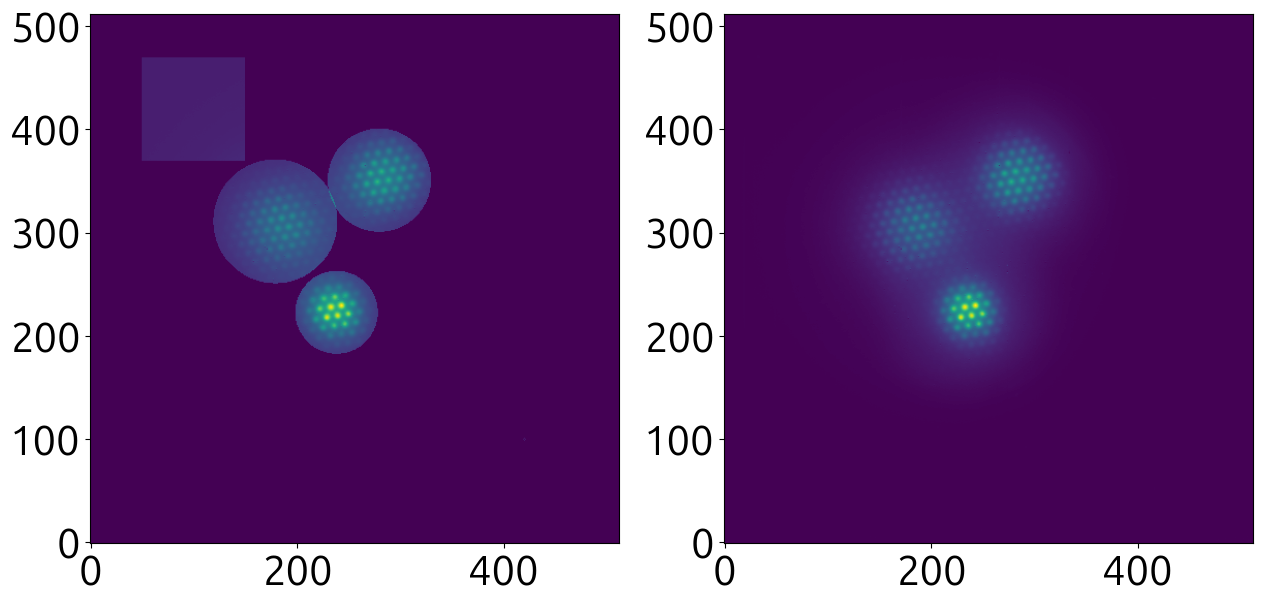

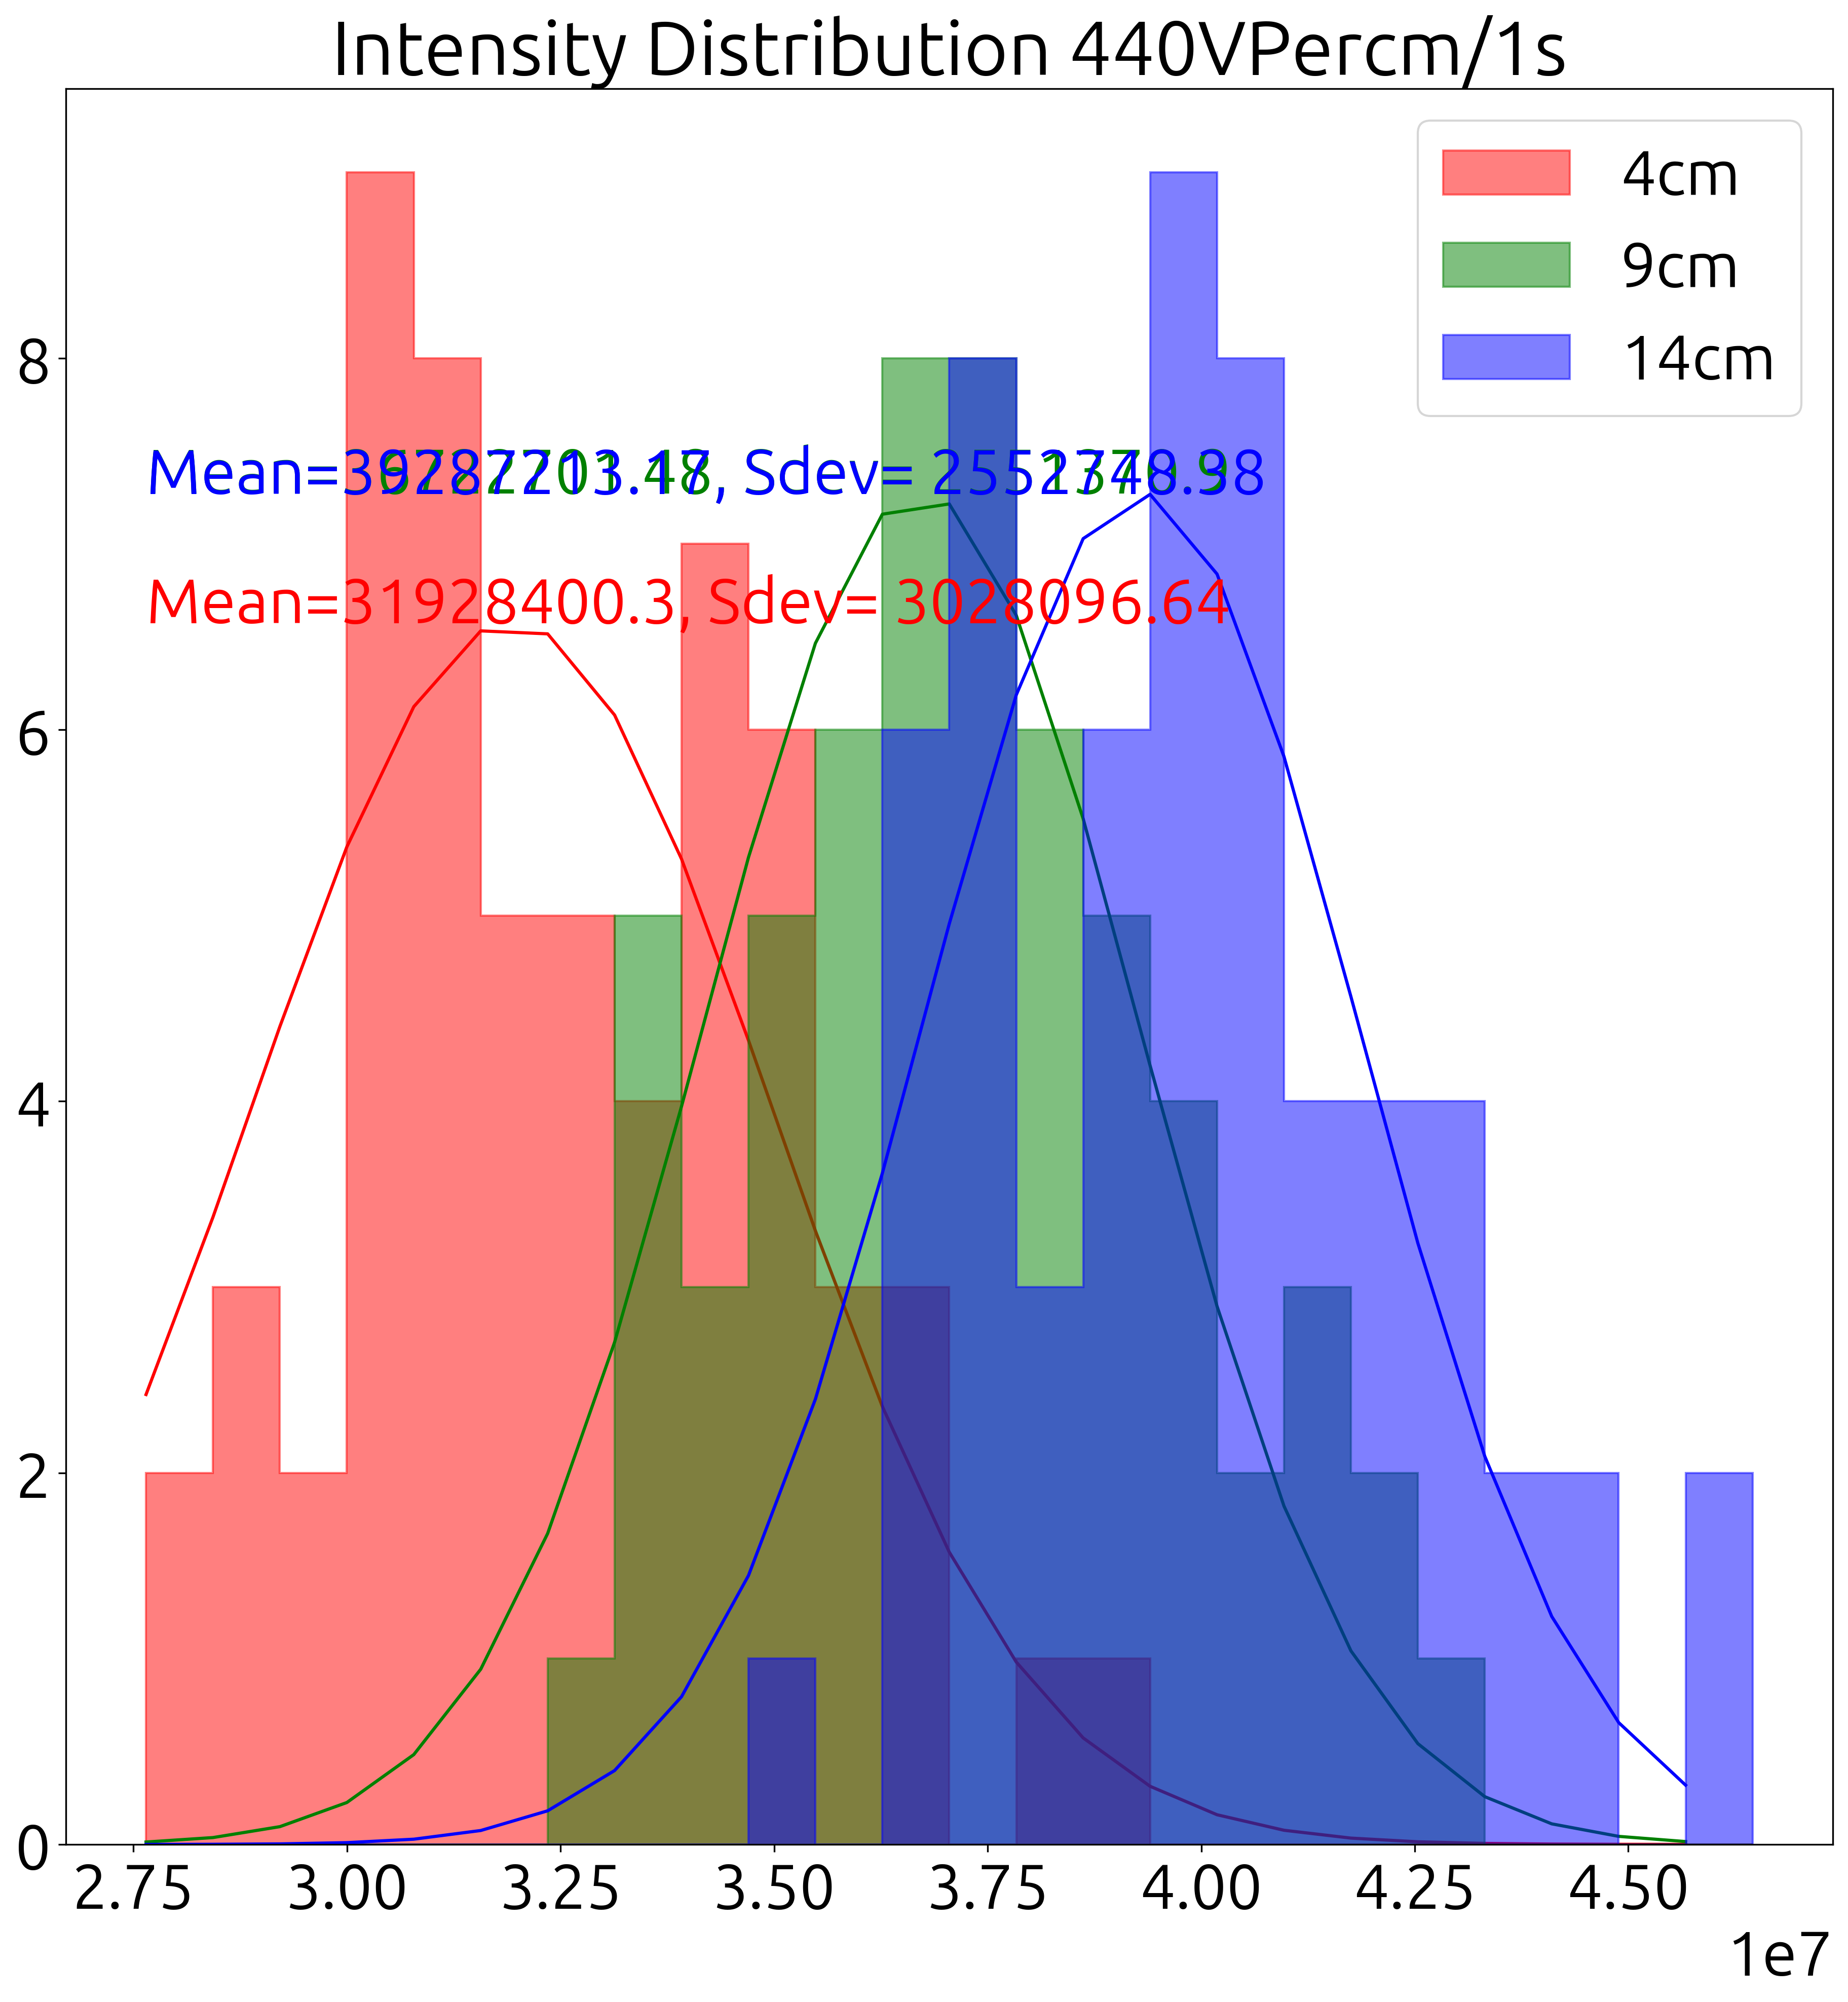

In [11]:
## Getting Xenon Hot Getter S2 Light Yields
#Path="/media/argon/CRAB/Xenon_Methane_Run_NewII/Hotgetter1_4.84/Hotgetter1_4.84/Camera/S2/"
Path="/media/argon/DATA/CRAB/Xenon_MethaneRun/Hot_Getter_4.98_day2/S2/"
XenonHotgetter=getLightyields(Path,["440VPercm/1s"],isplot=True,Avg=Avg)

In [12]:
#Path="../data/10bar_7days_purified/Camera/CRAB_9_17_2023/17k_8k_7k/22ms/" #(For Slides)
#Path="/media/argon/CRAB/Argon/day2/Pure_Argon_LENS1/S2/22ms"
#Path="/media/argon/Ilker_SSD/XenonRunNewII/8.08bar/S2/440Vpercm/22ms"
#Path="/media/argon/CRAB/XenonRun_NEWII/5.89_Bar/Camera/S2/440Vpercm/22ms/"
#Path="/home/argon/Projects/Ilker/CRAB_Diffusion/data/8.07bar/S2/440V/22ms/"
#Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/5.89_bar/S2/13.5k_8k_7k_II_1.5/440Vpercm/1s/"
#Path="/media/argon/Data/CRAB_NEW_II/data/6bar/22ms"
#Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/5.89_bar/S2/13.5k_8k_7k_II_1.5/440Vpercm/22ms/"



In [13]:
Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/XeMethane_4_85/S2/"
XeCH4_ColdTrap1=getLightyields(Path,["440VPercm/1s","125VPercm/1s"],isplot=False,Avg=Avg)

Analyzing 440VPercm/1s
Analyzing 125VPercm/1s
Skipping  14cm


In [14]:
## Getting Xenon Hot Getter S2 Light Yields
Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/XeCH4_4.98/S2/"
XeCH4_ColdTrap2=getLightyields(Path,["440VPercm/1s","125VPercm/1s"],isplot=False,Avg=Avg)

Analyzing 440VPercm/1s
Analyzing 125VPercm/1s
Skipping  14cm


In [15]:
Path="/media/argon/CRAB/Xenon_Methane_Run_NewII/Xenon-Methane_5_ColdTrap3/S2/"
XeCH4_ColdTrap3=getLightyields(Path,["440VPercm/1s","125VPercm/1s"],isplot=False,Avg=Avg)

Analyzing 440VPercm/1s
Analyzing 125VPercm/1s


In [16]:
XenonHotgetter["440VPercm/1s"]

((array([31928400.3 , 36722701.48, 39287213.17]),
  array([3028096.64, 2551370.9 , 2552748.38])),
 {'4cm': array([36669071.97996801, 33100142.01891243, 34236112.13082767,
         31908587.84946021, 33259978.64282287, 28863020.5437425 ,
         28538550.10067973, 31237211.43726509, 33576128.99508197,
         35322742.03618553, 38999187.26761296, 34897723.99460216,
         33589161.07305078, 30355072.03286685, 30618511.99092363,
         34807237.26101559, 35100272.60595762, 30569875.56877249,
         31323212.23322671, 29866264.89096361, 34004099.09140344,
         32886735.79868053, 30238645.51967213, 30195517.85013995,
         30345862.84690124, 31184530.76857257, 31962658.37101159,
         31440915.09536185, 29940349.7189924 , 34094777.18536586,
         34305486.5307477 , 31891139.90451819, 27647189.96673331,
         34181746.78568573, 30307714.17469013, 33908777.34014394,
         32478328.39972012, 35285005.57169132, 35368567.7627349 ,
         35834115.75037985, 29075548.

In [17]:


Err=np.array([np.sum((XenonHotgetter["440VPercm/1s"][0][1]/XenonHotgetter["440VPercm/1s"][0][0])**2),
    np.sum((XeCH4_ColdTrap3["440VPercm/1s"][0][1]/XeCH4_ColdTrap3["440VPercm/1s"][0][0])**2+(XenonHotgetter["440VPercm/1s"][0][1]/XenonHotgetter["440VPercm/1s"][0][0])**2),
    np.sum((XeCH4_ColdTrap2["440VPercm/1s"][0][1]/XeCH4_ColdTrap2["440VPercm/1s"][0][0])**2+(XenonHotgetter["440VPercm/1s"][0][1]/XenonHotgetter["440VPercm/1s"][0][0])**2),
    np.sum((XeCH4_ColdTrap1["440VPercm/1s"][0][1]/XeCH4_ColdTrap1["440VPercm/1s"][0][0])**2+(XenonHotgetter["440VPercm/1s"][0][1]/XenonHotgetter["440VPercm/1s"][0][0])**2)])
Error0=np.sqrt(Err)

#Normalizer=(XenonHotgetter["440VPercm/1s"][0][0]*Error0[0])+XenonHotgetter["440VPercm/1s"][0][0]
Normalizer=(XenonHotgetter["440VPercm/1s"][0][0])
Means0=np.array([np.mean((XenonHotgetter["440VPercm/1s"][0][0]/Normalizer)),
np.mean(XeCH4_ColdTrap3["440VPercm/1s"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap2["440VPercm/1s"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap1["440VPercm/1s"][0][0]/Normalizer)])
Error0=np.sqrt(Err)*Means0


In [18]:
XenonHotgetter["440VPercm/1s"][0][1]

array([3028096.64, 2551370.9 , 2552748.38])

In [19]:
RGAGasConcentration=np.array([0,0.101,0.174,0.338])
RGAGasConcentrationError=np.array([0,0.010,0.004,0.003])

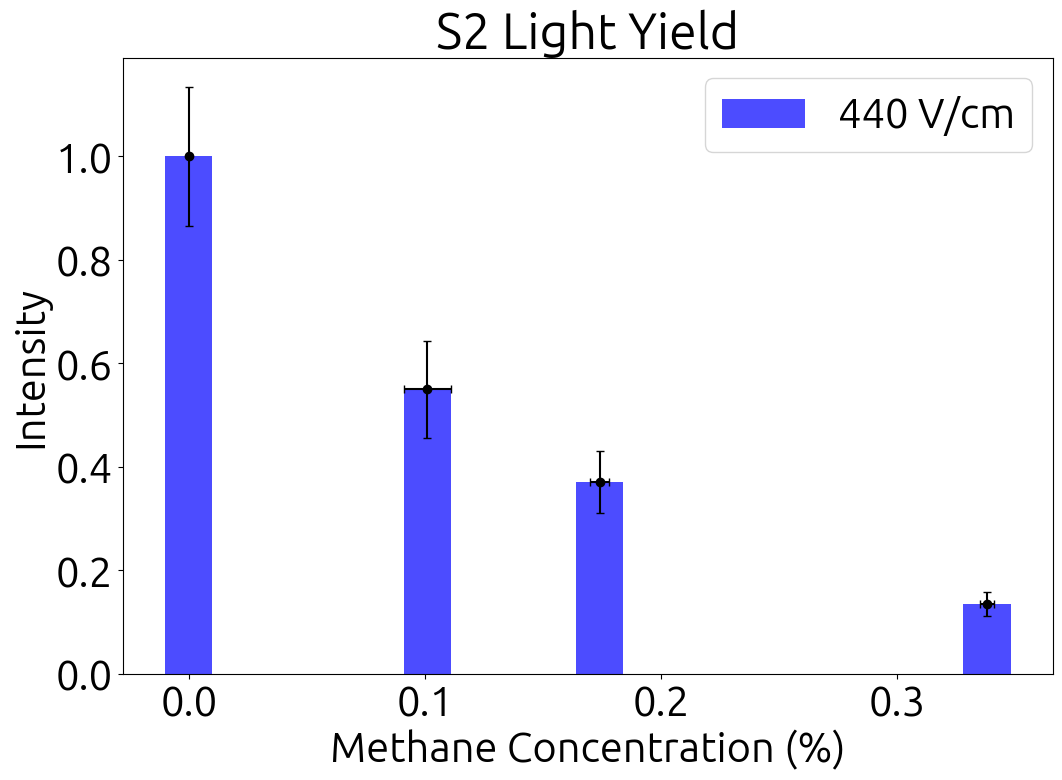

In [20]:
import seaborn as sns
plt.figure(figsize=(12,8))
plt.title("S2 Light Yield")

#plt.bar(np.array([100,90,70,60]),height=Means1,color="blue",width=1,label="125 V/cm")
#plt.errorbar(np.array([100,90,70,60]),Means1,yerr=Error1,capsize=3,fmt="-o",linestyle='',color="black")
plt.bar(RGAGasConcentration,height=Means0,color="blue",width=0.02,label="440 V/cm",alpha=0.7)
plt.errorbar(RGAGasConcentration,Means0,yerr=Error0,xerr=RGAGasConcentrationError,capsize=3,fmt="-o",linestyle='',color="black")
#plt.bar(np.array([100,90,70,60])-1,height=Means1,color="red",width=1,label="125 V/cm",alpha=0.7)
#plt.errorbar(np.array([100,90,70,60])-1,Means1,yerr=Error1,capsize=3,fmt="-o",linestyle='',color="black")

plt.ylabel("Intensity")
plt.xlabel("Methane Concentration (%)")
plt.legend()

In [21]:
print(f"Means {Means0}")
print(f"Error {Error0}")

Means [1.         0.5496573  0.37142591 0.1339396 ]
Error [0.13432658 0.09362092 0.0600195  0.02322207]


In [ ]:


Err=np.array([np.sum((XenonHotgetter["440VPercm/1s"][0][1]/XenonHotgetter["440VPercm/1s"][0][0])**2),
    np.sum((XeCH4_ColdTrap3["440VPercm/1s"][0][1]/XeCH4_ColdTrap3["440VPercm/1s"][0][0])**2+(XenonHotgetter["440VPercm/1s"][0][1]/XenonHotgetter["440VPercm/1s"][0][0])**2),
    np.sum((XeCH4_ColdTrap2["440VPercm/1s"][0][1]/XeCH4_ColdTrap2["440VPercm/1s"][0][0])**2+(XenonHotgetter["440VPercm/1s"][0][1]/XenonHotgetter["440VPercm/1s"][0][0])**2),
    np.sum((XeCH4_ColdTrap1["440VPercm/1s"][0][1]/XeCH4_ColdTrap1["440VPercm/1s"][0][0])**2+(XenonHotgetter["440VPercm/1s"][0][1]/XenonHotgetter["440VPercm/1s"][0][0])**2)])
Error0=np.sqrt(Err)

#Normalizer=(XenonHotgetter["440VPercm/1s"][0][0]*Error0[0])+XenonHotgetter["440VPercm/1s"][0][0]
Normalizer=(XenonHotgetter["440VPercm/1s"][0][0])
Means0=np.array([np.mean((XenonHotgetter["440VPercm/1s"][0][0]/Normalizer)),
np.mean(XeCH4_ColdTrap3["440VPercm/1s"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap2["440VPercm/1s"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap1["440VPercm/1s"][0][0]/Normalizer)])
Error0=np.sqrt(Err)*Means0


Analyzing 440Vpercm/1s


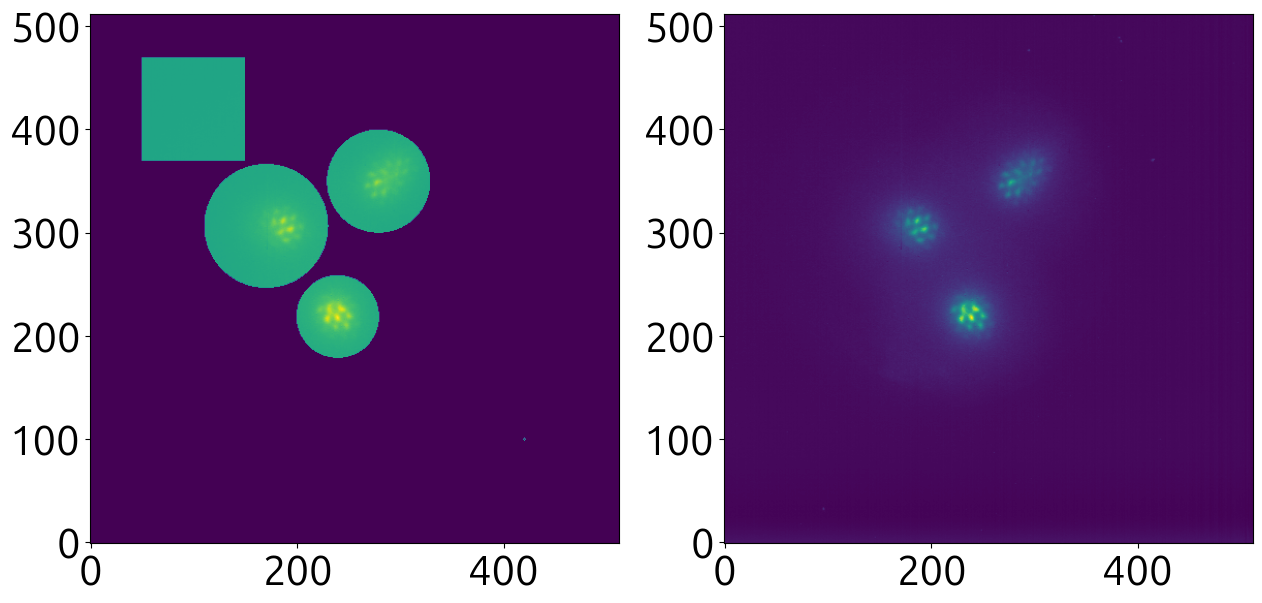

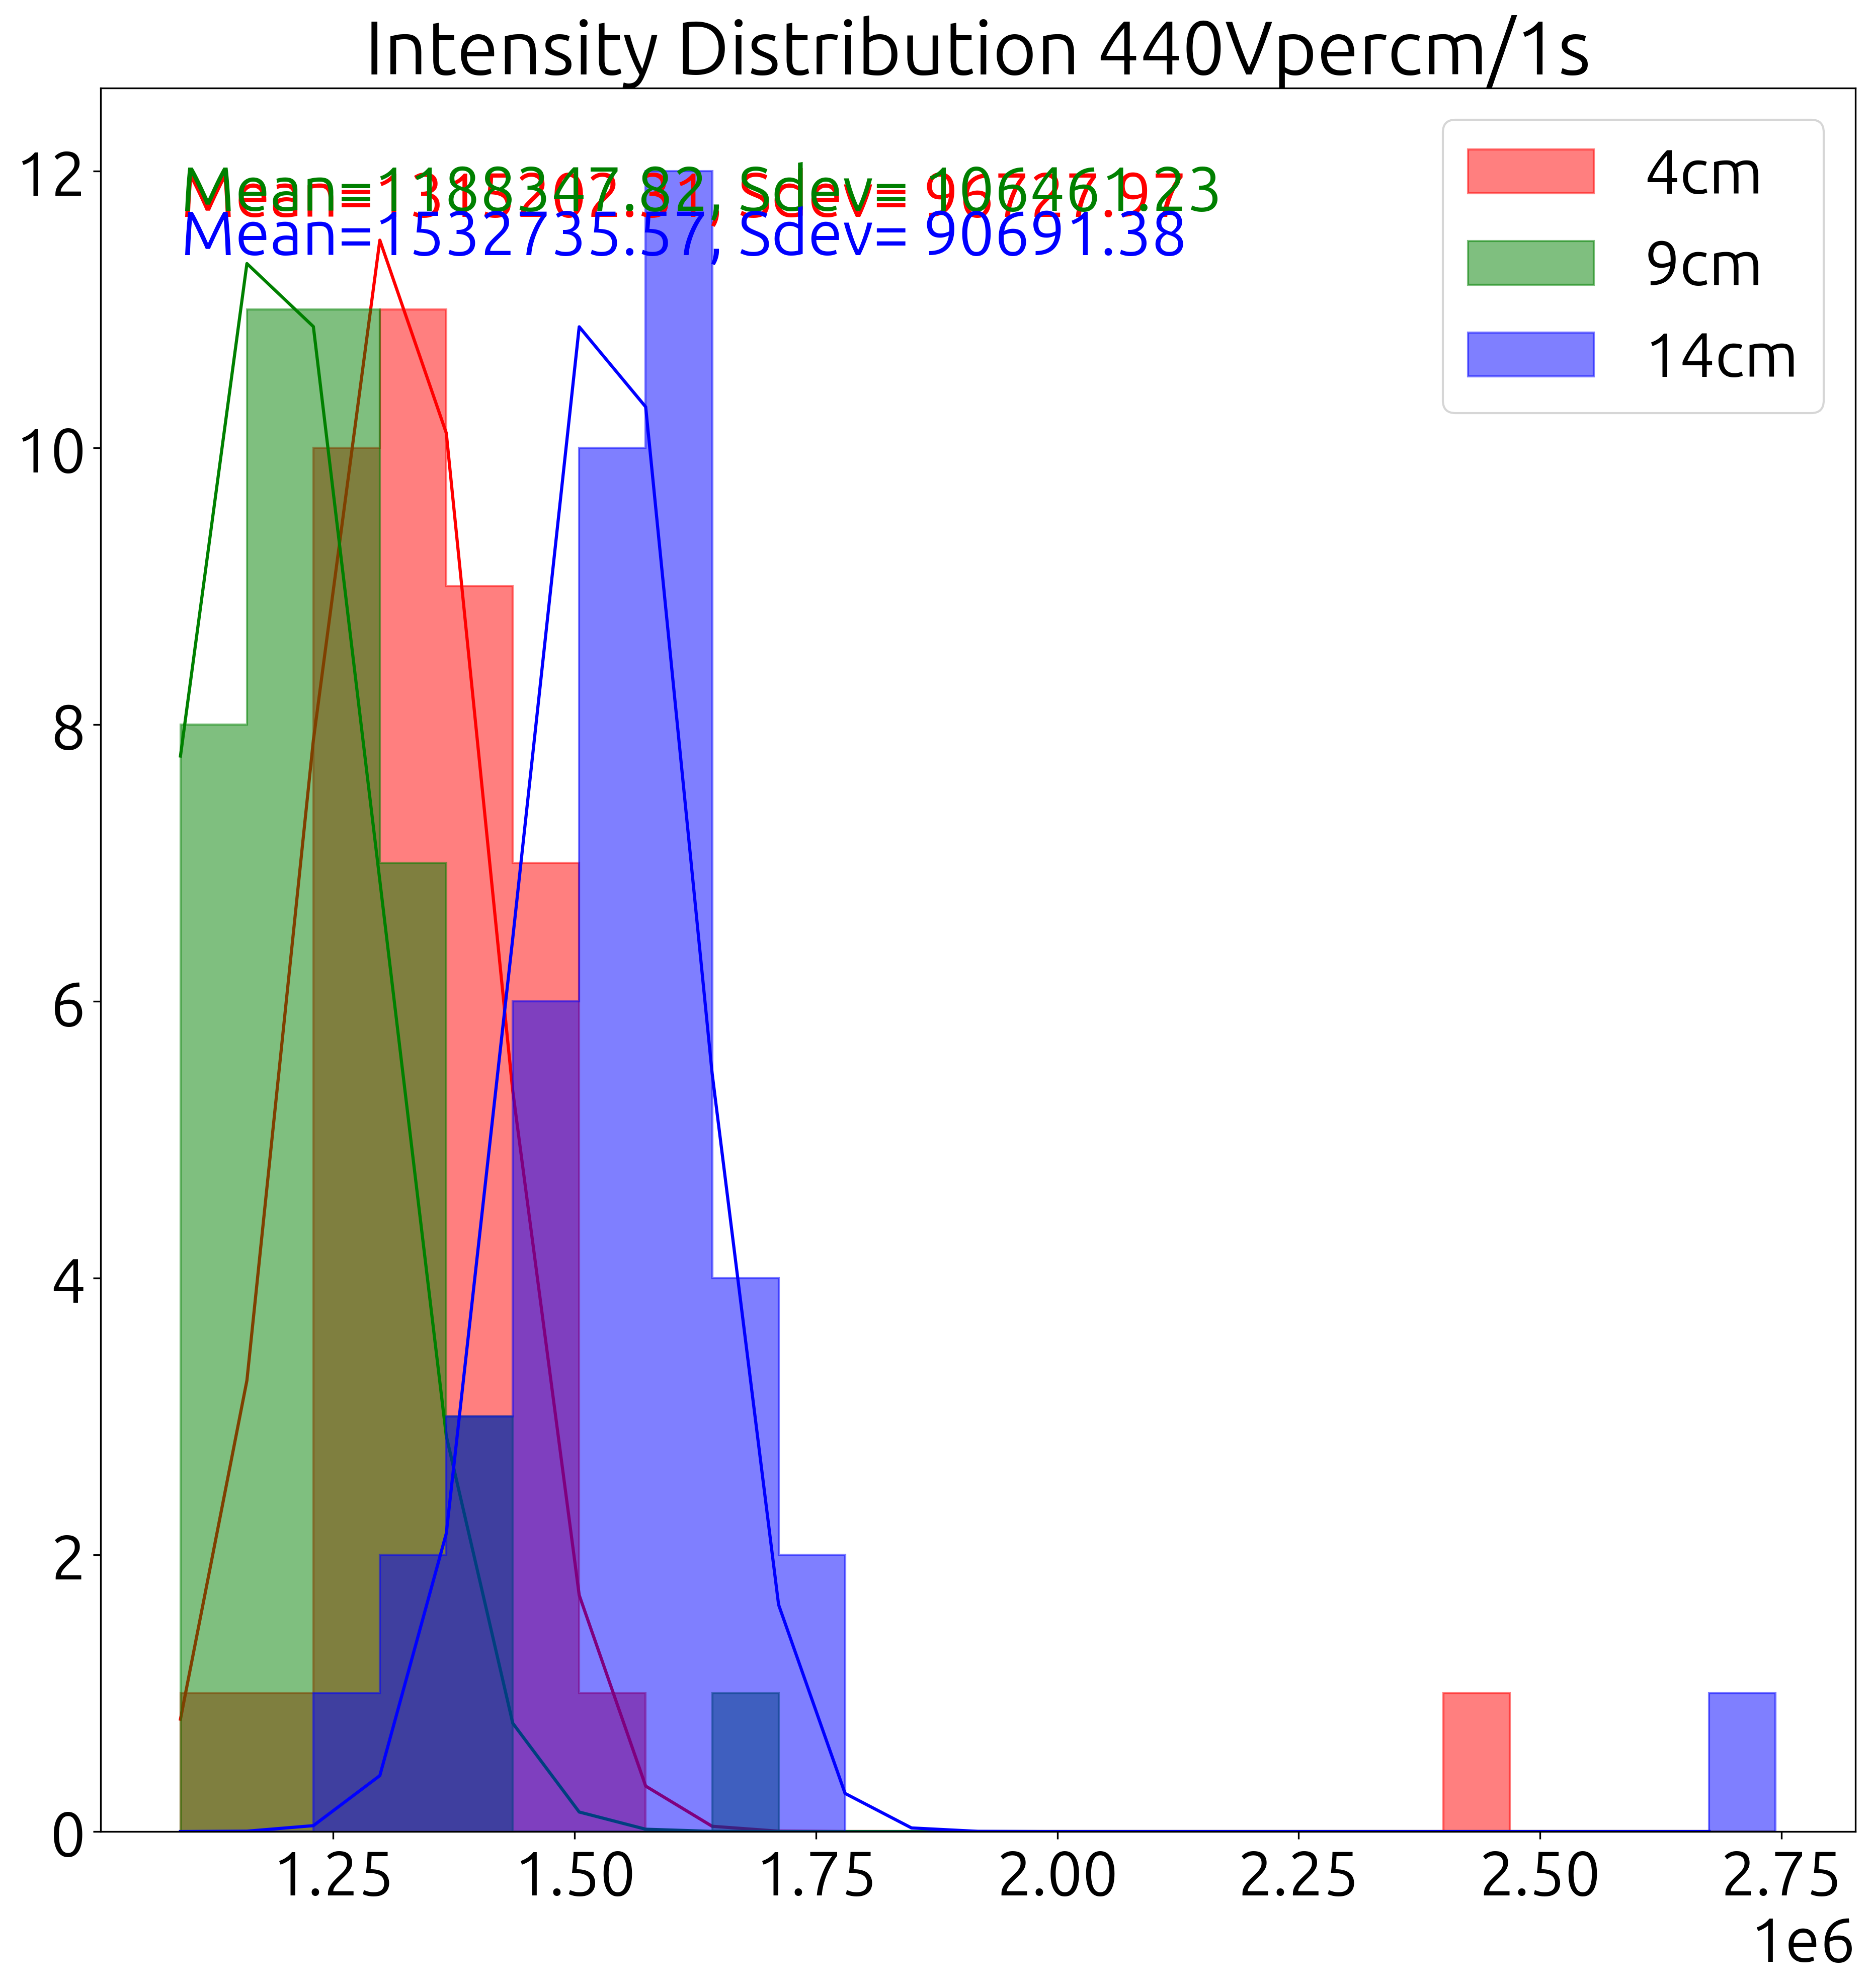

Analyzing 125Vpercm/1s


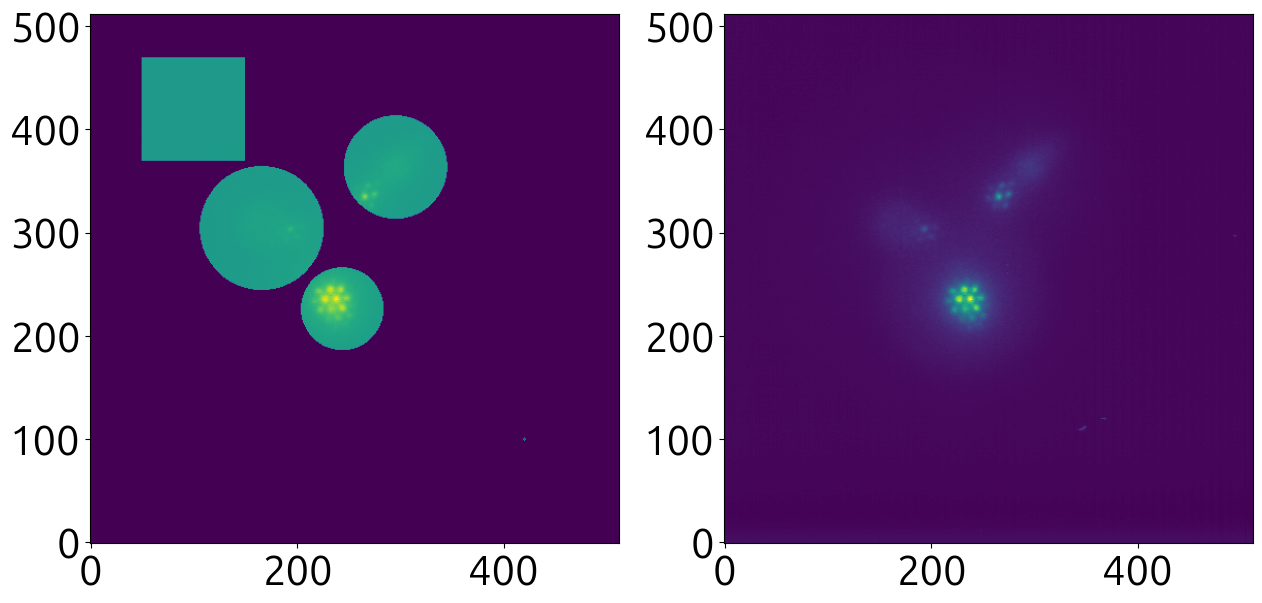

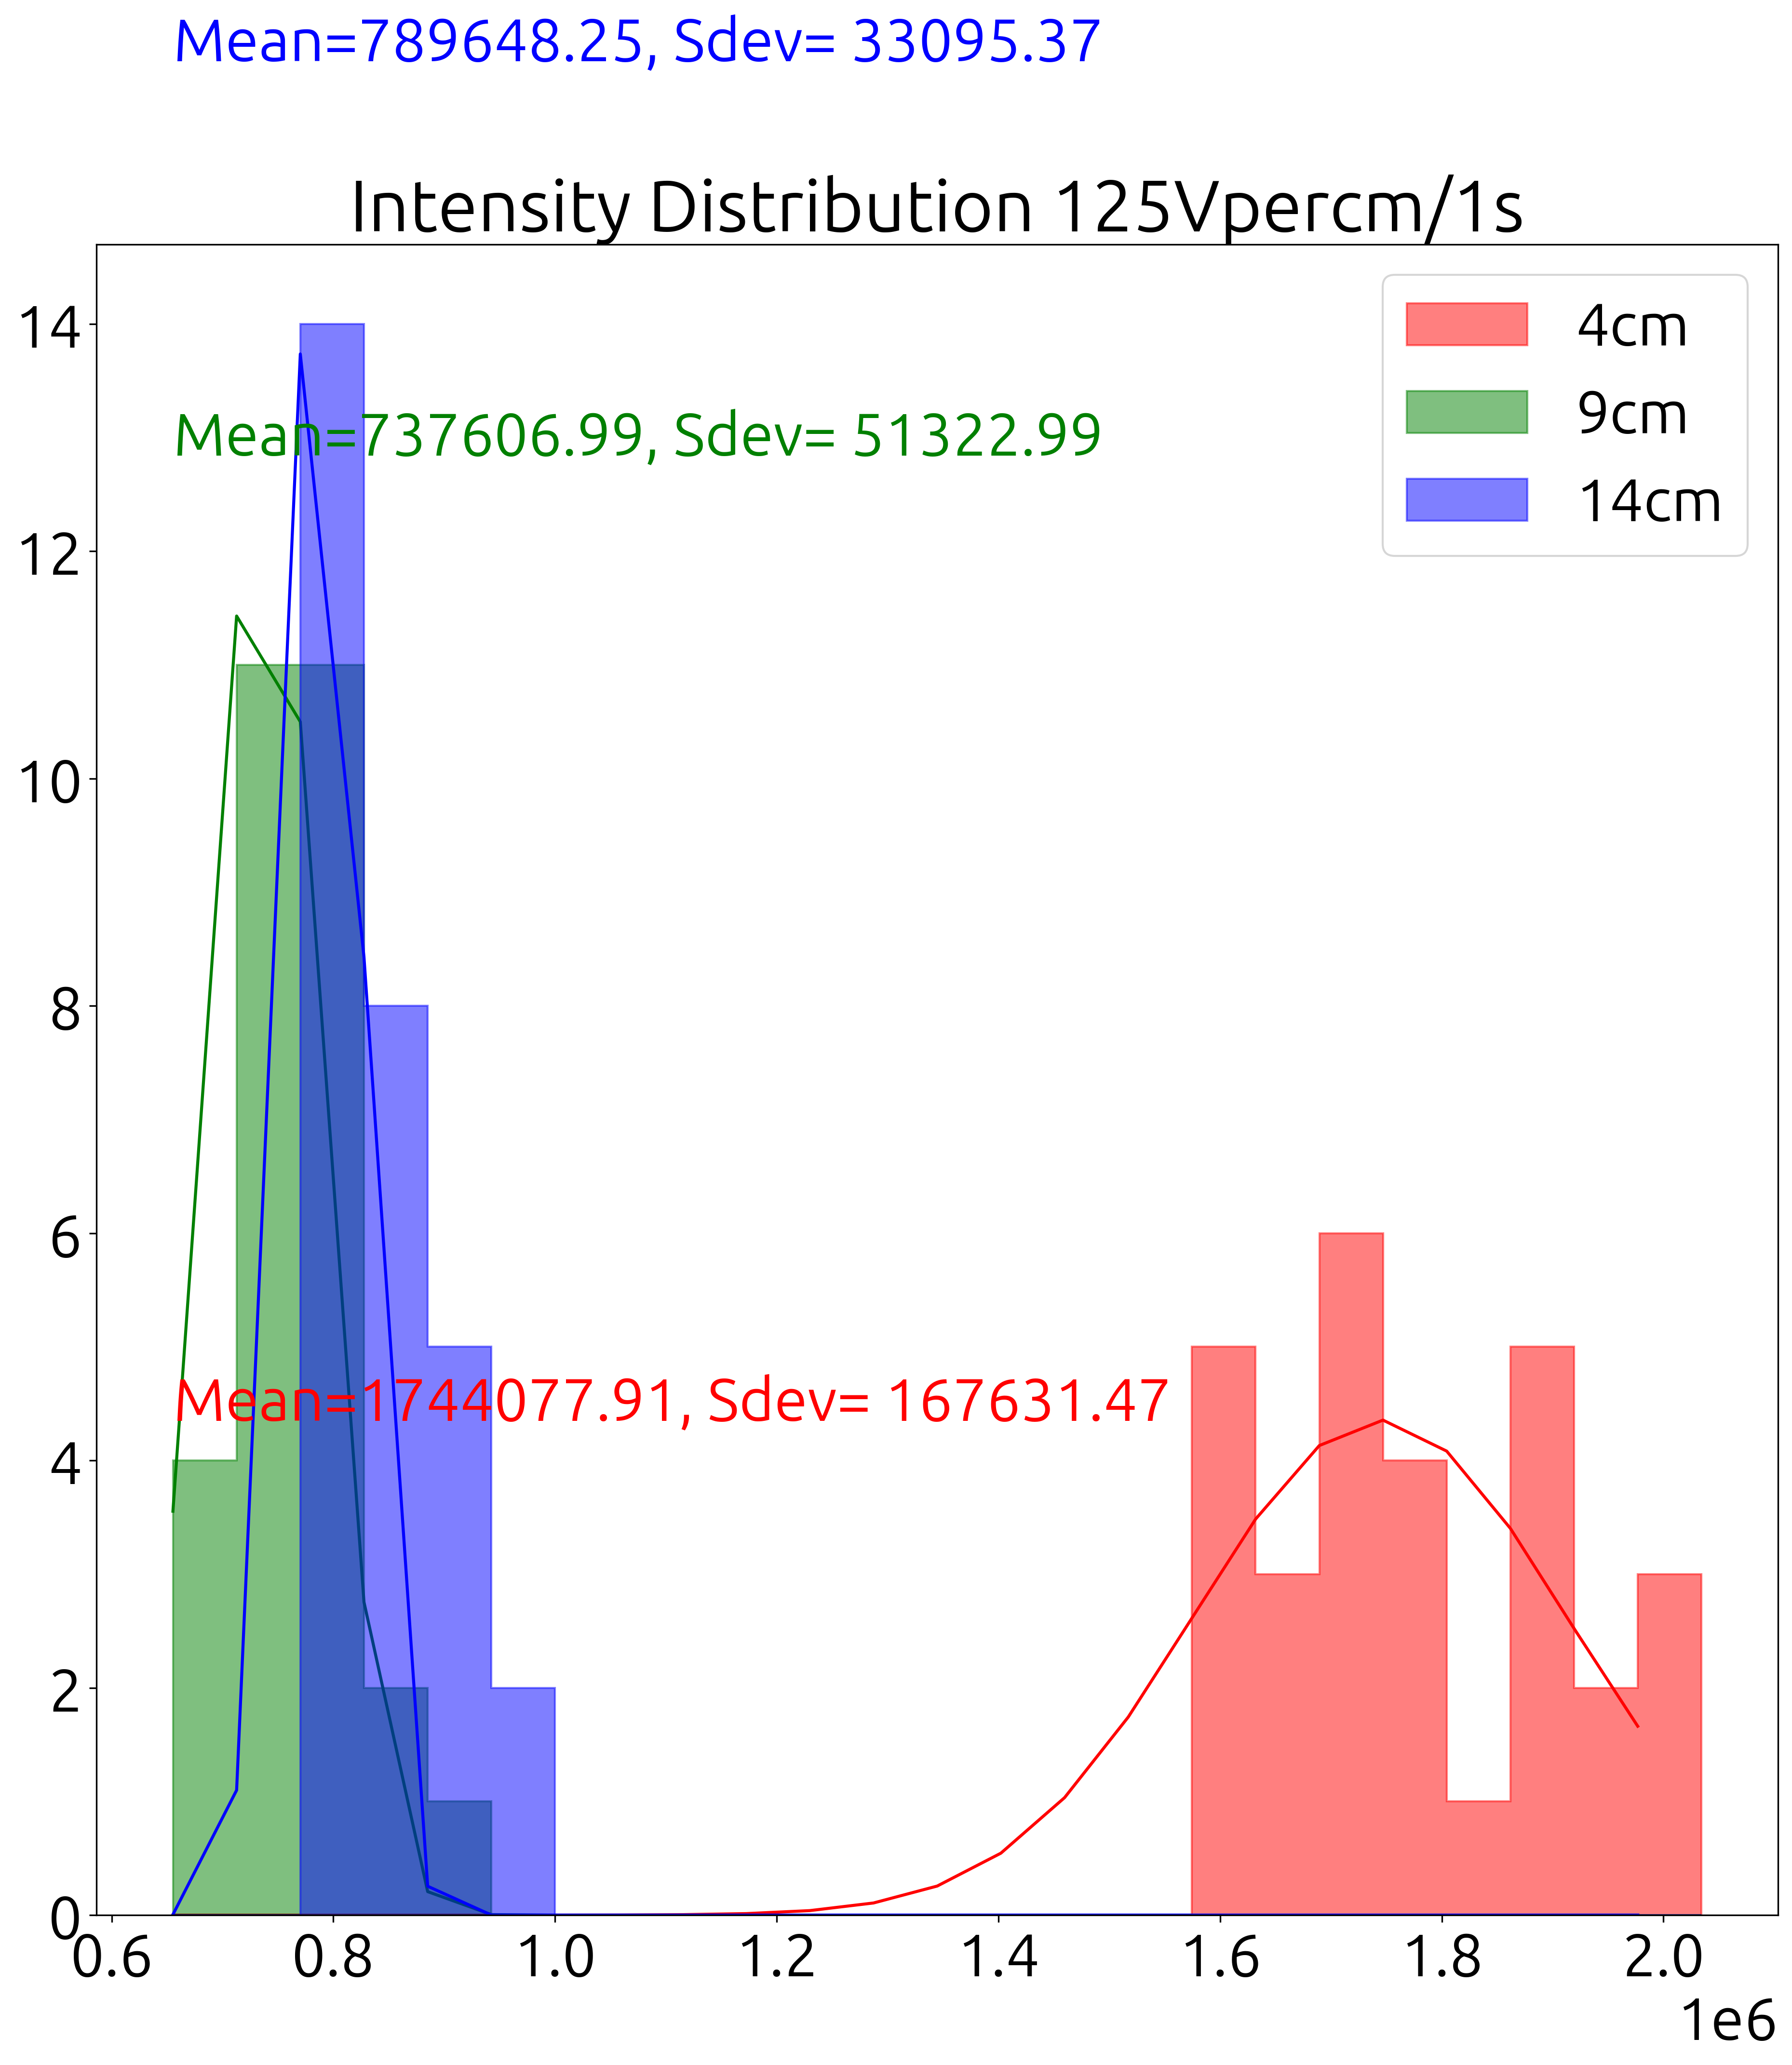

In [19]:
Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/5.89_bar/S2/13.5k_8k_7k_II_1.5/"
XeCH4_6barMethane=getLightyields(Path,["440Vpercm/1s","125Vpercm/1s"],isplot=True,Avg=Avg)

Analyzing 440Vpercm/1s


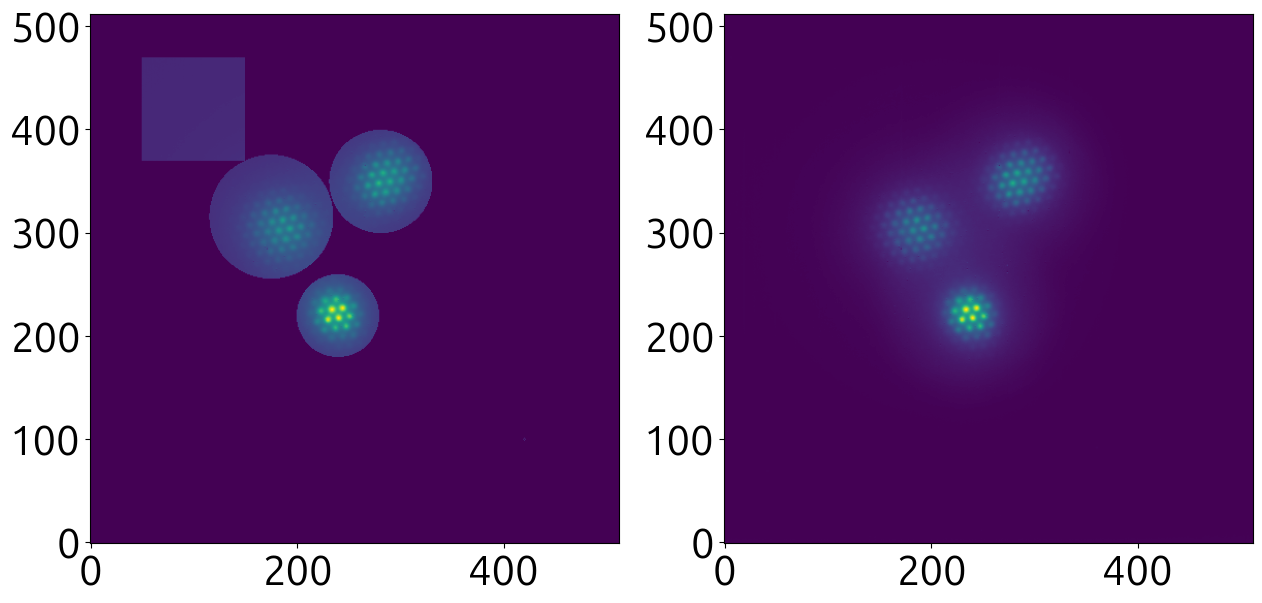

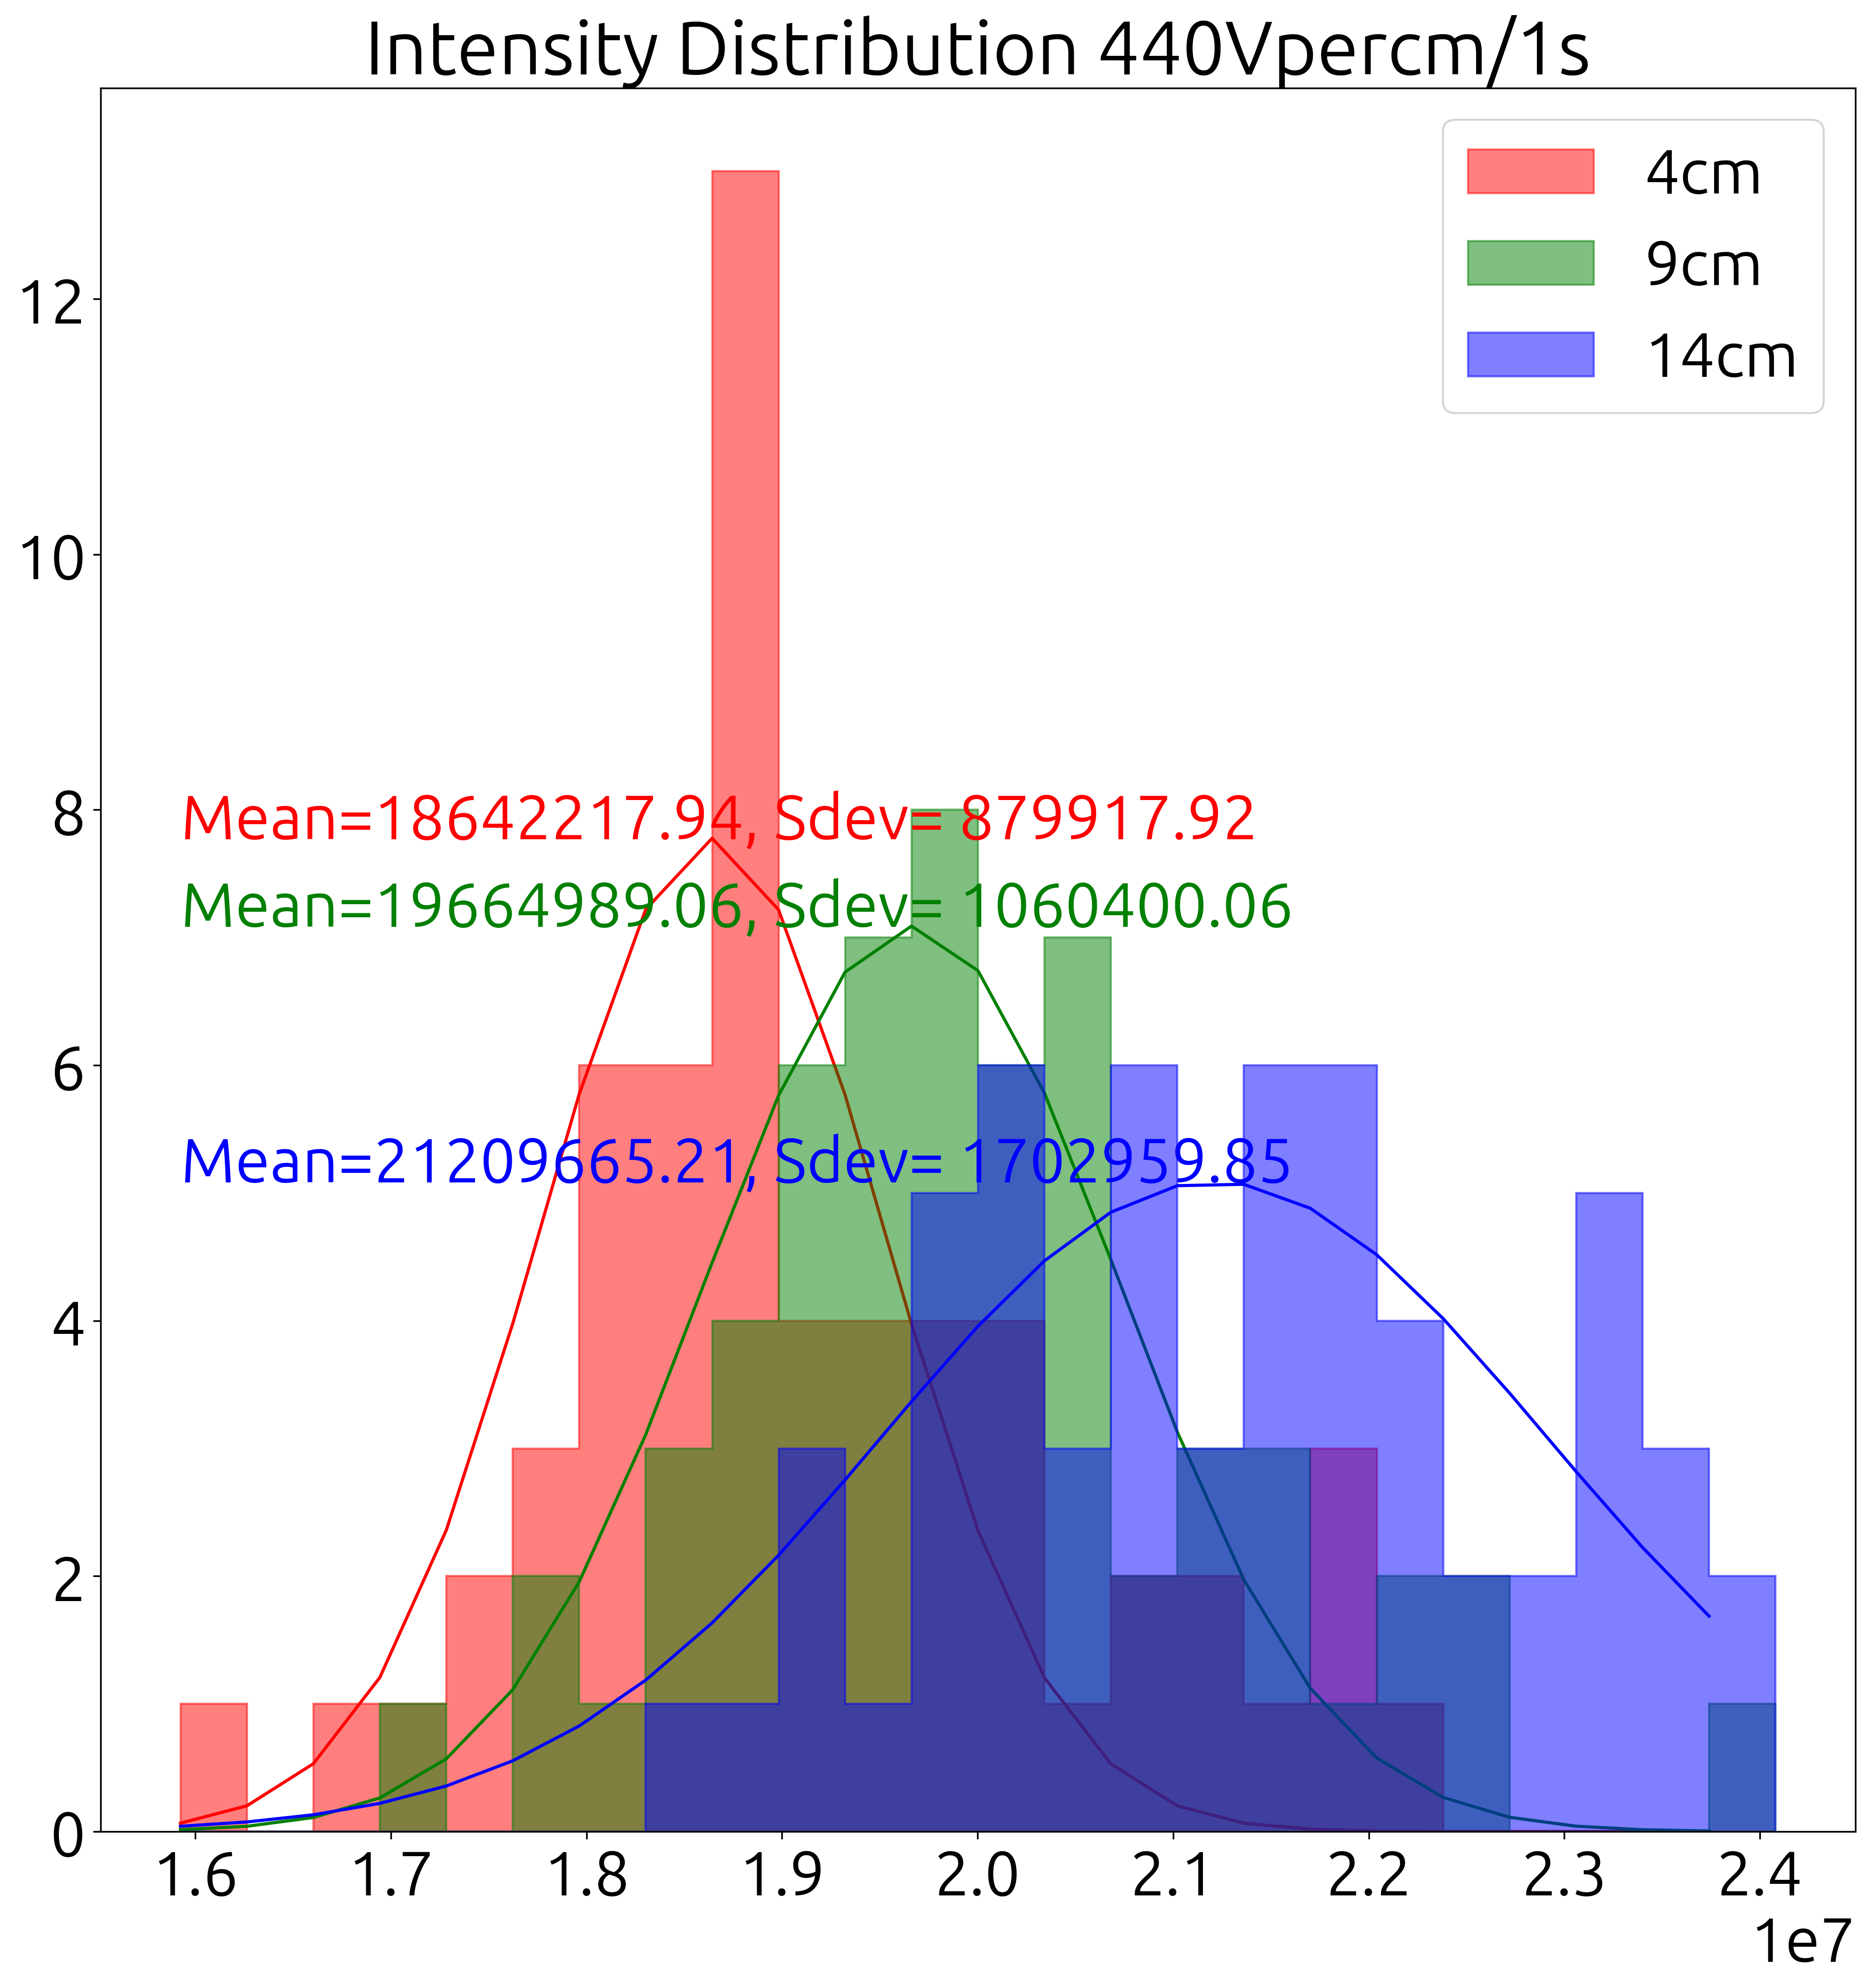

Analyzing 125Vpercm/1s


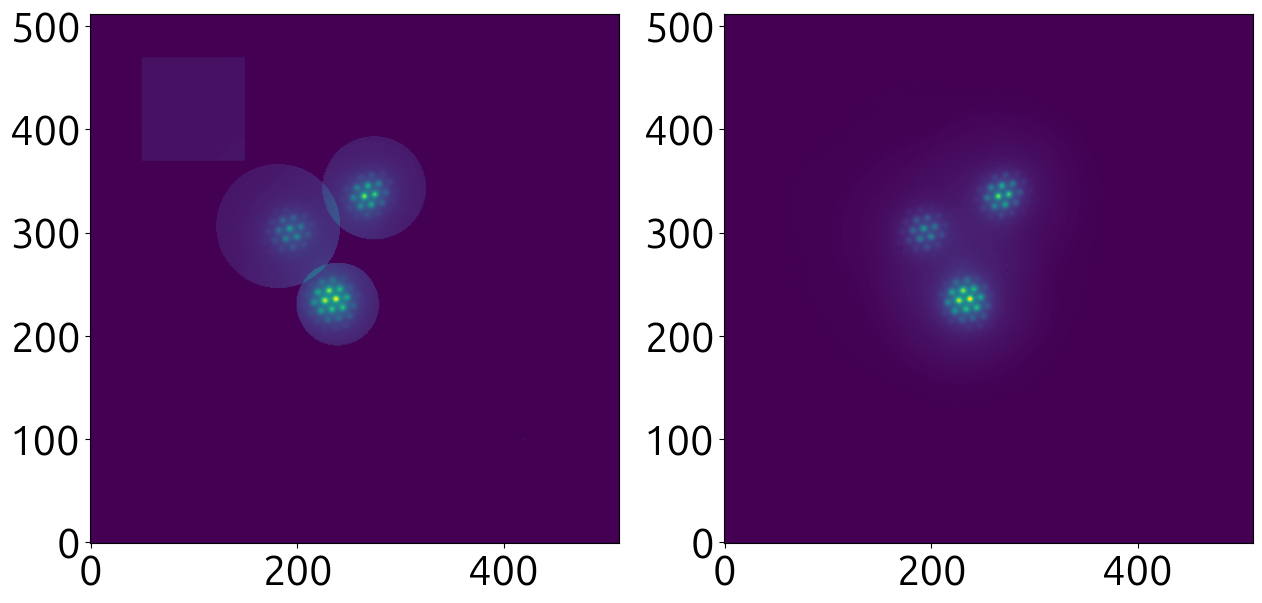

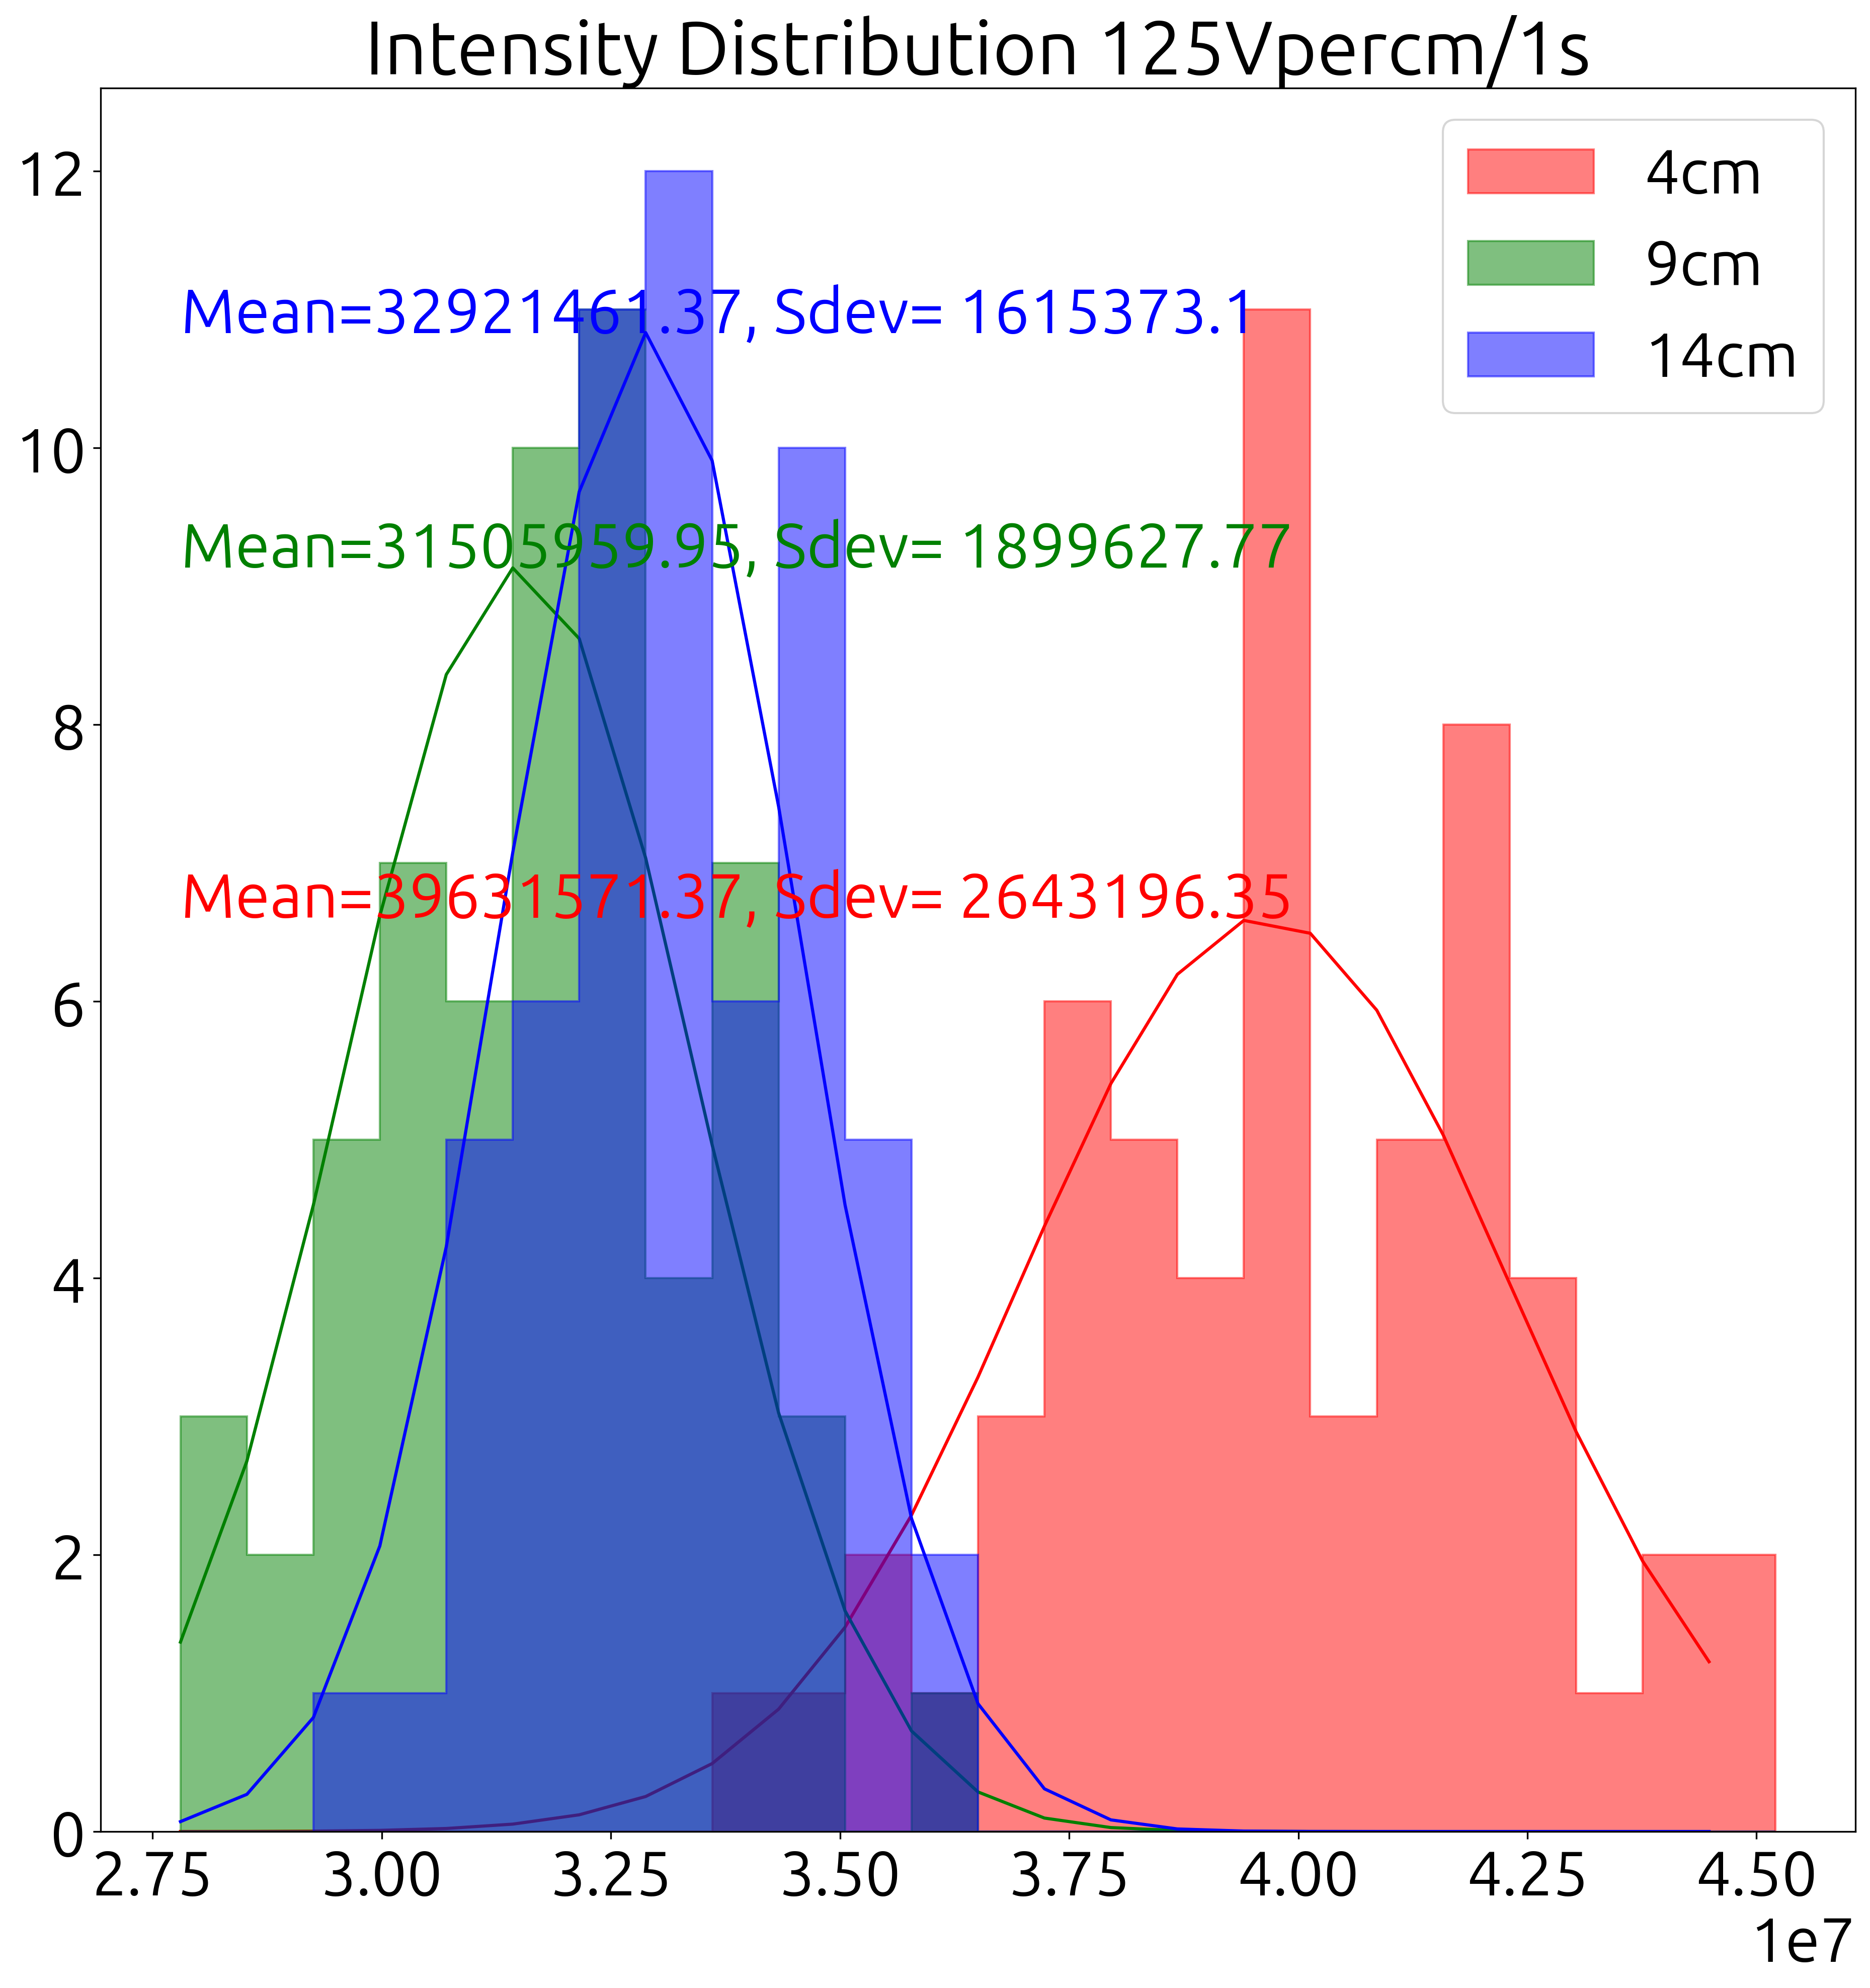

In [18]:
Path="/media/argon/DATA/CRAB/XenonRunNewII/5.89_Bar/Camera/S2/"
XeCH4_6bar=getLightyields(Path,["440Vpercm/1s","125Vpercm/1s"],isplot=True,Avg=Avg)

In [27]:


Err=np.array([np.sum((XeCH4_6bar["440Vpercm/1s"][0][1]/XeCH4_6bar["440Vpercm/1s"][0][0])**2),
    np.sum((XeCH4_6barMethane["440Vpercm/1s"][0][1]/XeCH4_6barMethane["440Vpercm/1s"][0][0])**2+(XeCH4_6bar["440Vpercm/1s"][0][1]/XeCH4_6bar["440Vpercm/1s"][0][0])**2)])
Error0=np.sqrt(Err)

#Normalizer=(XenonHotgetter["440VPercm/1s"][0][0]*Error0[0])+XenonHotgetter["440VPercm/1s"][0][0]
Normalizer=(XeCH4_6bar["440Vpercm/1s"][0][0])

Means0=np.array([np.mean((XeCH4_6bar["440Vpercm/1s"][0][0])/Normalizer),
np.mean(XeCH4_6barMethane["440Vpercm/1s"][0][0]/Normalizer)])
Error0=np.sqrt(Err)*Means0


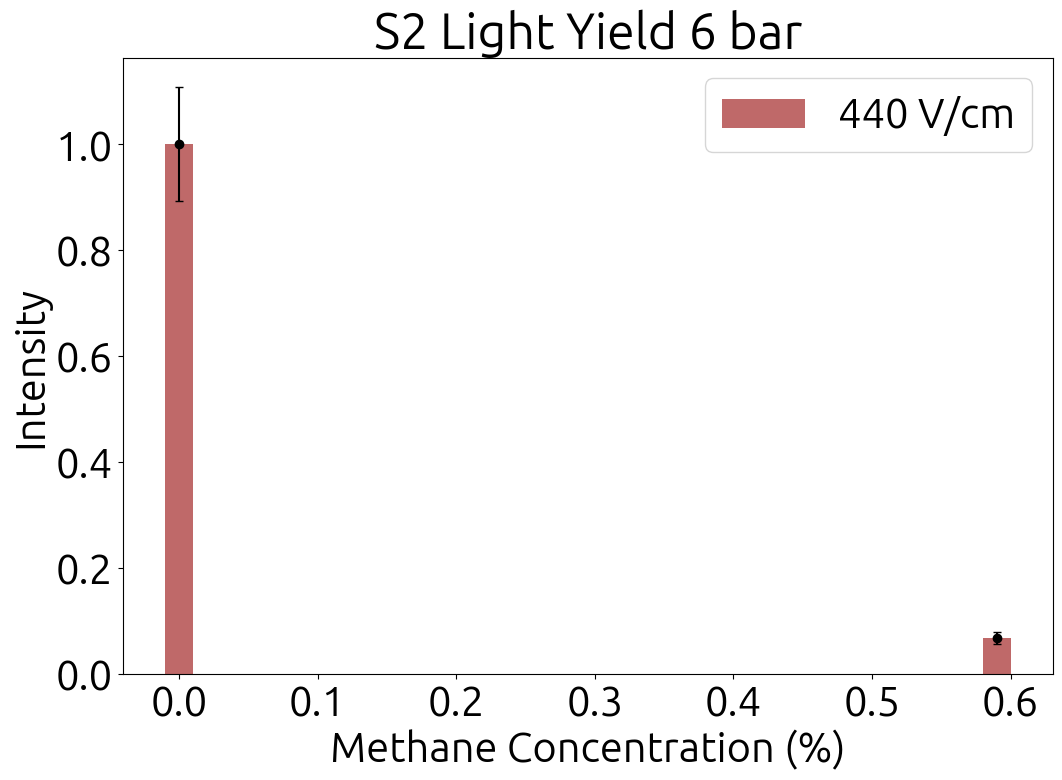

In [30]:
import seaborn as sns
plt.figure(figsize=(12,8))
plt.title("S2 Light Yield 6 bar")

#plt.bar(np.array([100,90,70,60]),height=Means1,color="blue",width=1,label="125 V/cm")
#plt.errorbar(np.array([100,90,70,60]),Means1,yerr=Error1,capsize=3,fmt="-o",linestyle='',color="black")
plt.bar([0,0.59],height=Means0,color="brown",width=0.02,label="440 V/cm",alpha=0.7)
plt.errorbar([0,0.59],Means0,yerr=Error0,xerr=[0,0],capsize=3,fmt="-o",linestyle='',color="black")
#plt.bar(np.array([100,90,70,60])-1,height=Means1,color="red",width=1,label="125 V/cm",alpha=0.7)
#plt.errorbar(np.array([100,90,70,60])-1,Means1,yerr=Error1,capsize=3,fmt="-o",linestyle='',color="black")

plt.ylabel("Intensity")
plt.xlabel("Methane Concentration (%)")
plt.legend()